# f6_m05_informe_final.ipynb

## Qué hace
Sintetiza todos los resultados de Fase 6 en un informe ejecutivo.
Lee los ficheros .parquet generados por cada submódulo y construye
un documento HTML con las conclusiones principales, el modelo recomendado,
hallazgos clave, limitaciones y recomendaciones institucionales.
Incluye 5 gráficos originales: mapa de riesgo del alumnado, burbuja SHAP,
semáforo de fairness, curva de robustez y embudo de clasificación.

## Requisitos
- Todos los .parquet de results/fase6/ (generados por m01a-m04c)
- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`

## Genera
- `results/fase6/informe_mapa_riesgo.png`
- `results/fase6/informe_burbuja_shap.png`
- `results/fase6/informe_semaforo_fairness.png`
- `results/fase6/informe_curva_robustez.png`
- `results/fase6/informe_embudo.png`
- `docs/html/fase6/m05_informe_final.html`

## Flujo
Leer resultados → generar 5 graficos → construir secciones HTML → escribir

## Siguiente
Fase 7 — Aplicación Streamlit

In [1]:
# 1. CONFIGURACIÓN DE RUTAS
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA    = ROOT / 'data' / '05_modelado'
DIR_MODELS  = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS = ROOT / 'results' / 'fase6'

print(f'ROOT:        {ROOT}')
print(f'DIR_RESULTS: {DIR_RESULTS}')

ROOT:        C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# 2. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import plotly.io as pio
import joblib
import base64
from src.html.render import render_pagina_desde_fichero

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print('Imports OK.')


Imports OK.


In [3]:
# 3. CARGAR TODOS LOS RESULTADOS DE FASE 6

def cargar_parquet(nombre: str) -> pd.DataFrame:
    ruta = DIR_RESULTS / nombre
    if not ruta.exists():
        print(f'  No encontrado: {nombre}')
        return pd.DataFrame()
    return pd.read_parquet(ruta)

df_shap_imp = cargar_parquet('shap_importancia_comparativa.parquet')
df_fairness = cargar_parquet('fairness_metricas.parquet')
df_errores  = cargar_parquet('errores_fpfn.parquet')
df_cal      = cargar_parquet('calibracion_metricas.parquet')
df_stress   = cargar_parquet('stress_resultados.parquet')
df_sos      = cargar_parquet('sostenibilidad_metricas.parquet')

# Datos de test para mapa de riesgo
X_test_prep  = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
y_test       = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()
pipeline_cat = joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl')

y_true = y_test.values.ravel()
y_prob = pipeline_cat.predict_proba(X_test_prep)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print('Todo cargado.')

Todo cargado.


In [4]:
# 4. CALCULAR MÉTRICAS RESUMEN

# SHAP top 5
top5_shap = df_shap_imp.nsmallest(5, 'rank_medio').index.tolist() if not df_shap_imp.empty else []

# Errores
conteo_tipos = df_errores['tipo'].value_counts() if not df_errores.empty else pd.Series()
total_test   = len(df_errores) if not df_errores.empty else 0
n_tp = conteo_tipos.get('TP', 0)
n_tn = conteo_tipos.get('TN', 0)
n_fp = conteo_tipos.get('FP', 0)
n_fn = conteo_tipos.get('FN', 0)
recall_global    = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else 0
precision_global = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else 0

# Calibración
mejor_cal   = df_cal.loc[df_cal['brier'].idxmin(), 'metodo'] if not df_cal.empty else 'N/A'
mejor_brier = df_cal['brier'].min() if not df_cal.empty else 0
brier_orig  = df_cal.loc[df_cal['metodo'] == 'Original', 'brier'].values[0] if not df_cal.empty else 0

# Stress
auc_baseline = 0.9308
stress_ruido = df_stress[df_stress['test'] == 'ruido'] if not df_stress.empty else pd.DataFrame()
auc_ruido_50 = stress_ruido[stress_ruido['nivel'] == 0.50]['auc'].values[0] if len(stress_ruido) else 0
caida_ruido  = auc_baseline - auc_ruido_50
stress_miss  = df_stress[df_stress['test'] == 'missing'] if not df_stress.empty else pd.DataFrame()
auc_miss_5   = stress_miss[stress_miss['n_features'] == 5]['auc'].values[0] if len(stress_miss) else 0
caida_miss   = auc_baseline - auc_miss_5

# Fairness
fair_res = df_fairness[['variable_sensible','dp_diff','eq_opp_diff']].drop_duplicates() if not df_fairness.empty else pd.DataFrame()

print('Métricas calculadas.')

Métricas calculadas.


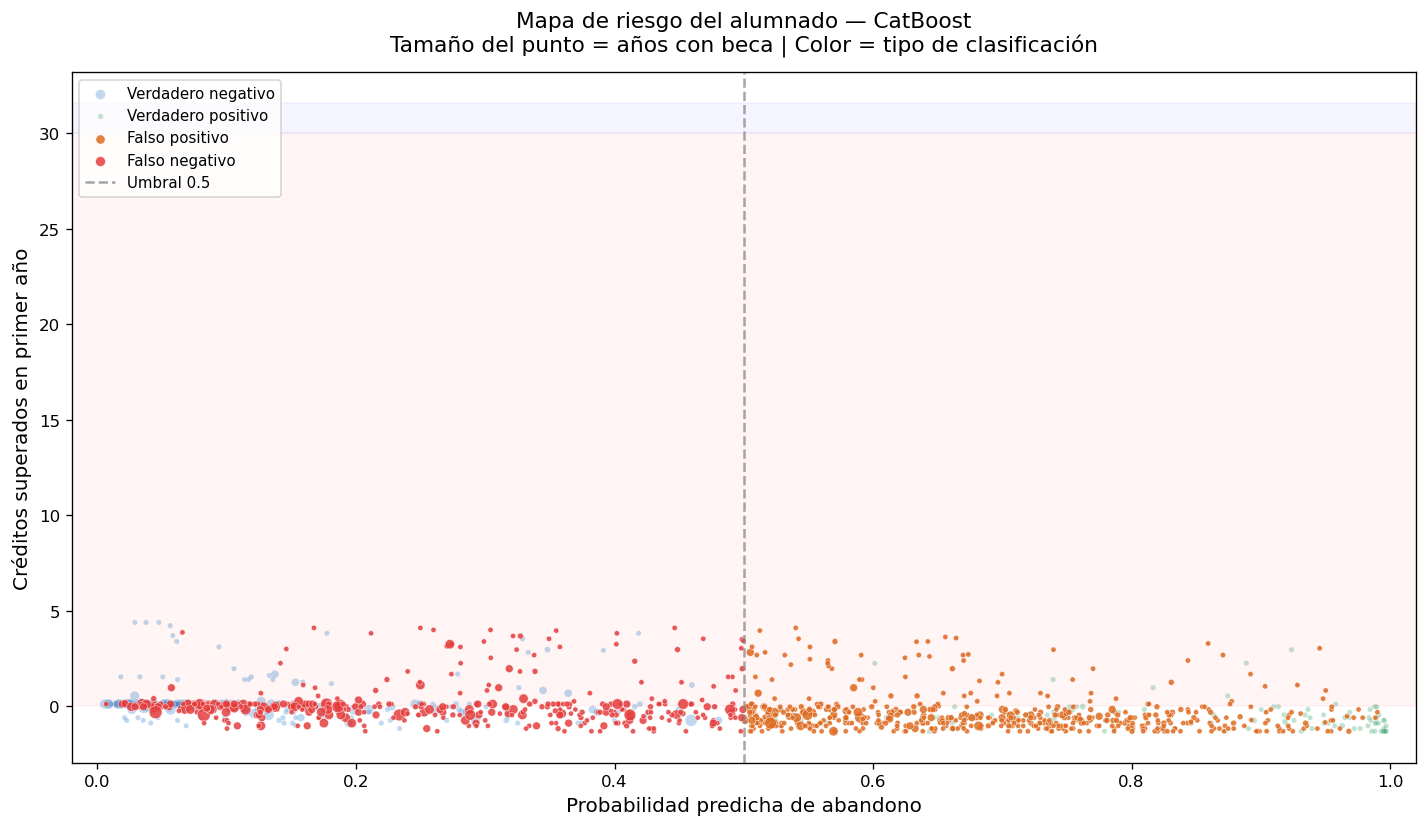

Mapa de riesgo guardado.


In [5]:
# 5. GRÁFICO 1 — MAPA DE RIESGO DEL ALUMNADO
# Scatter: eje X = prob abandono, eje Y = créditos 1er año.
# ylim recortado al percentil 99. Outliers anotados con flecha.

tipo_cls = np.where(
    (y_true == 1) & (y_pred == 1), 'TP',
    np.where((y_true == 0) & (y_pred == 0), 'TN',
    np.where((y_true == 0) & (y_pred == 1), 'FP', 'FN'))
)

features_num = X_test_prep.select_dtypes(include=[np.number]).columns.tolist()

df_plot = pd.DataFrame({
    'prob':         y_prob,
    'cred_1er':     X_test_prep['cred_superados_anio_1er'].values,
    'n_anios_beca': X_test_prep['n_anios_beca'].values,
    'y_true':       y_true,
    'tipo':         tipo_cls,
})

df_correctos  = df_plot[df_plot['tipo'].isin(['TP','TN'])].sample(300, random_state=42)
df_errores_pl = df_plot[df_plot['tipo'].isin(['FP','FN'])]
df_scatter    = pd.concat([df_correctos, df_errores_pl])

colores_tipo = {'TP':'#38a169','TN':'#3182ce','FP':'#dd6b20','FN':'#e53e3e'}
etiquetas    = {'TP':'Verdadero positivo','TN':'Verdadero negativo',
                'FP':'Falso positivo','FN':'Falso negativo'}

# ylim: percentil 99 + margen
y_p99 = np.percentile(df_scatter['cred_1er'], 99)
y_top = max(y_p99 * 1.15, 12)
n_out = int((df_scatter['cred_1er'] > y_top).sum())

fig, ax = plt.subplots(figsize=(12, 6))

for t in ['TN','TP','FP','FN']:
    mask  = df_scatter['tipo'] == t
    sub   = df_scatter[mask]
    size  = np.clip(sub['n_anios_beca'] * 15 + 10, 10, 120)
    alpha = 0.3 if t in ['TP','TN'] else 0.85
    ax.scatter(sub['prob'], sub['cred_1er'].clip(upper=y_top),
               c=colores_tipo[t], s=size, alpha=alpha,
               label=etiquetas[t], edgecolors='white', linewidths=0.3)

# Anotar outliers recortados
out_df = df_scatter[df_scatter['cred_1er'] > y_top]
for _, row in out_df.iterrows():
    ax.annotate(
        f'outlier: {int(row["cred_1er"])} créd.',
        xy=(row['prob'], y_top),
        xytext=(row['prob'] + 0.05, y_top * 0.88),
        fontsize=7, color='#718096',
        arrowprops=dict(arrowstyle='->', color='#718096', lw=0.8),
    )

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Umbral 0.5')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-1, y_top)
ax.set_xlabel('Probabilidad predicha de abandono', fontsize=12)
ax.set_ylabel('Créditos superados en primer año', fontsize=12)
ax.set_title(
    'Mapa de riesgo del alumnado — CatBoost\n'
    'Tamaño del punto = años con beca | Color = tipo de clasificación',
    fontsize=13, pad=12
)
ax.legend(fontsize=9, loc='upper left')
if n_out > 0:
    ax.text(0.98, 0.97,
            f'* {n_out} obs. fuera de rango anotadas',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#718096', style='italic')

plt.tight_layout()
ruta_mapa = DIR_RESULTS / 'informe_mapa_riesgo.png'
plt.savefig(ruta_mapa, dpi=120, bbox_inches='tight')
plt.show()
print(f'Mapa de riesgo guardado. ylim=[-1, {y_top:.1f}], outliers: {n_out}')


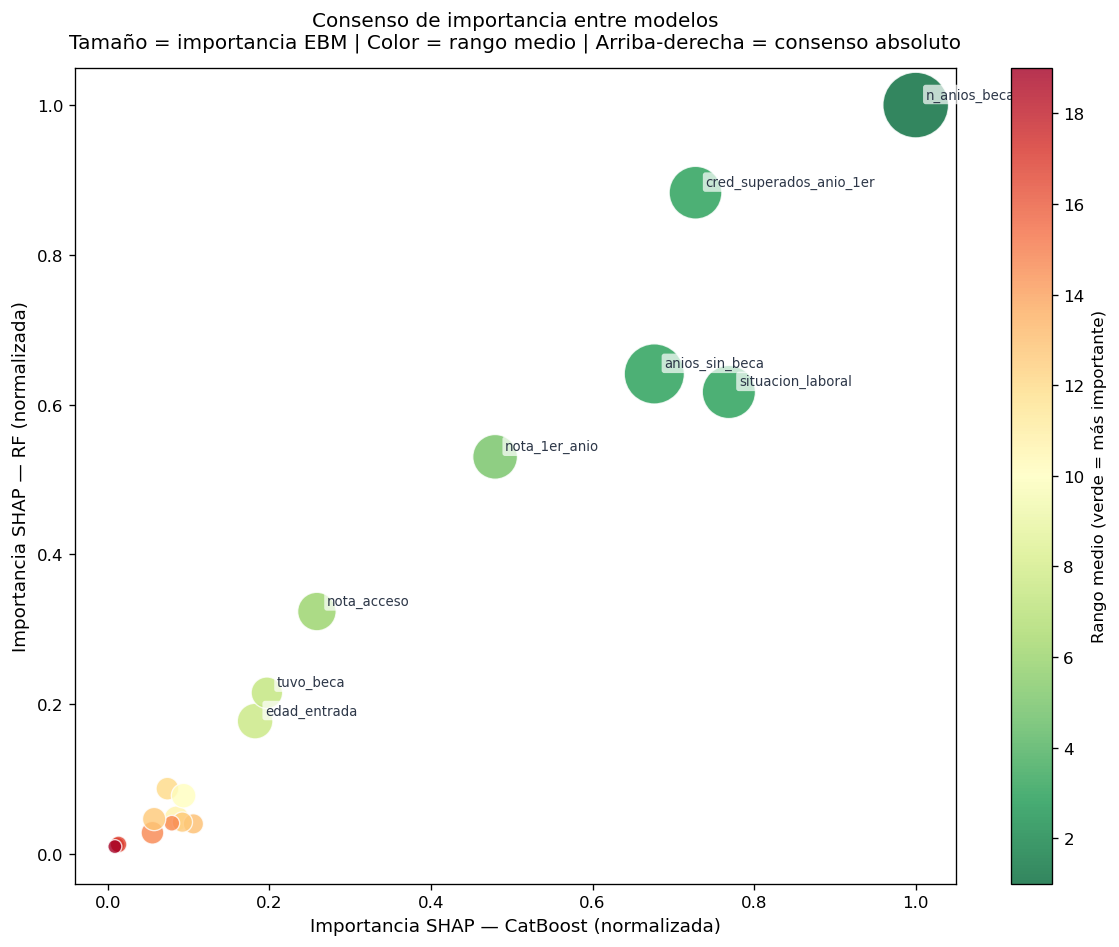

Burbuja SHAP guardada.


In [6]:
# 6. GRÁFICO 2 — BURBUJA SHAP (plotly interactivo con hover)
# Eje X = importancia CatBoost, eje Y = importancia RF,
# tamaño = importancia EBM, color = rango medio.

NOMBRES_LEGIBLES = {
    'n_anios_beca':            'Años con beca',
    'anios_sin_beca':          'Años sin beca',
    'cred_superados_anio_1er': 'Créditos superados 1er año',
    'situacion_laboral':       'Situación laboral',
    'nota_1er_anio':           'Nota 1er año',
    'nota_acceso':             'Nota de acceso',
    'tuvo_beca':               'Tuvo beca',
    'edad_entrada':            'Edad de entrada',
    'sexo':                    'Sexo',
    'max_pagos':               'Máx. pagos por curso',
    'rama':                    'Rama de conocimiento',
    'via_acceso':              'Vía de acceso',
    'anios_gap':               'Años de gap',
    'indicador_interrupcion':  'Interrupción formal',
    'tipo_acceso':             'Tipo de acceso',
    'n_convocatorias':         'Nº convocatorias',
    'curso_cohorte':           'Curso de entrada',
}

if not df_shap_imp.empty:
    df_bur = df_shap_imp.copy()
    for col in ['CatBoost', 'RF', 'EBM']:
        df_bur[col] = df_bur[col] / df_bur[col].max()

    nombres = [NOMBRES_LEGIBLES.get(f, f.replace('_', ' ')) for f in df_bur.index]

    fig_bur = go.Figure(go.Scatter(
        x=df_bur['CatBoost'],
        y=df_bur['RF'],
        mode='markers',
        marker=dict(
            size=df_bur['EBM'] * 55 + 8,
            color=df_bur['rank_medio'],
            colorscale='RdYlGn_r',
            colorbar=dict(title='Rango medio', thickness=14, len=0.7),
            opacity=0.82,
            line=dict(color='white', width=0.8),
        ),
        text=nombres,
        customdata=list(zip(
            df_bur['CatBoost'].round(3),
            df_bur['RF'].round(3),
            df_bur['EBM'].round(3),
            df_bur['rank_medio'].round(1),
        )),
        hovertemplate=(
            '<b>%{text}</b><br>'
            'CatBoost: %{customdata[0]}<br>'
            'RF: %{customdata[1]}<br>'
            'EBM: %{customdata[2]}<br>'
            'Rank medio: %{customdata[3]}'
            '<extra></extra>'
        ),
    ))
    fig_bur.update_layout(
        title=dict(
            text='Consenso de importancia entre modelos<br>'
                 '<sup>Tamaño = importancia EBM | Color = rango medio | '
                 'Arriba-derecha = consenso absoluto</sup>',
            font=dict(size=13),
        ),
        xaxis=dict(title='Importancia SHAP — CatBoost (normalizada)', tickfont=dict(size=10)),
        yaxis=dict(title='Importancia SHAP — RF (normalizada)', tickfont=dict(size=10)),
        width=780, height=580,
        plot_bgcolor='#f7fafc',
        paper_bgcolor='white',
        margin=dict(t=80, b=60, l=70, r=80),
    )

    ruta_burbuja_html = DIR_RESULTS / 'informe_burbuja_shap.html'
    ruta_burbuja_png  = DIR_RESULTS / 'informe_burbuja_shap.png'
    fig_bur.write_html(str(ruta_burbuja_html), include_plotlyjs='cdn', full_html=False)
    try:
        fig_bur.write_image(str(ruta_burbuja_png), scale=1.5)
        print('PNG guardado.')
    except Exception as e:
        print(f'PNG no disponible (necesita kaleido): {e}')
    fig_bur.show()
    print('Burbuja SHAP guardada.')
else:
    ruta_burbuja_html = Path('no_existe')
    ruta_burbuja_png  = Path('no_existe')


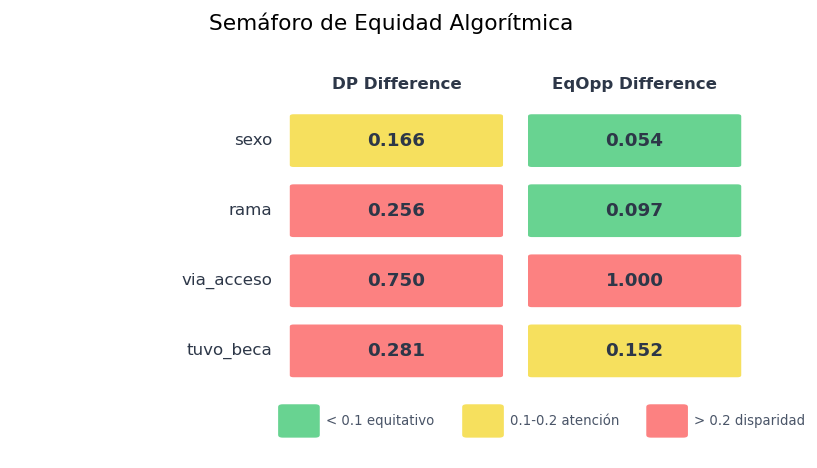

Semáforo guardado.


In [7]:
# 7. GRÁFICO 3 — SEMÁFORO DE FAIRNESS
# Heatmap con colores rojo/amarillo/verde según umbrales de equidad.
# Filas = variables sensibles, columnas = métricas de fairness.

if not fair_res.empty:
    vars_fair   = fair_res['variable_sensible'].tolist()
    metricas_f  = ['dp_diff', 'eq_opp_diff']
    etiq_met    = ['DP Difference', 'EqOpp Difference']

    # Matriz de valores
    matriz = fair_res.set_index('variable_sensible')[metricas_f].abs()

    # Colores semáforo: verde <0.1, amarillo <0.2, rojo >=0.2
    def color_semaforo(val):
        if val < 0.1:  return '#68d391'  # verde
        elif val < 0.2: return '#f6e05e'  # amarillo
        else:           return '#fc8181'  # rojo

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axis('off')

    for i, var in enumerate(vars_fair):
        for j, met in enumerate(metricas_f):
            val = matriz.loc[var, met]
            color = color_semaforo(val)
            rect = mpatches.FancyBboxPatch(
                (j * 2.2 + 0.1, len(vars_fair) - i - 0.85),
                1.9, 0.7,
                boxstyle='round,pad=0.05',
                facecolor=color, edgecolor='white', linewidth=2
            )
            ax.add_patch(rect)
            ax.text(j * 2.2 + 1.05, len(vars_fair) - i - 0.5,
                    f'{val:.3f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='#2d3748')

        ax.text(-0.1, len(vars_fair) - i - 0.5, var,
                ha='right', va='center', fontsize=10, color='#2d3748')

    for j, etiq in enumerate(etiq_met):
        ax.text(j * 2.2 + 1.05, len(vars_fair) + 0.3, etiq,
                ha='center', va='center', fontsize=10,
                fontweight='bold', color='#2d3748')

    # Leyenda
    for x, (c, txt) in enumerate([
        ('#68d391', '< 0.1 equitativo'),
        ('#f6e05e', '0.1-0.2 atención'),
        ('#fc8181', '> 0.2 disparidad')
    ]):
        rect = mpatches.FancyBboxPatch(
            (x * 1.7, -0.7), 0.3, 0.4,
            boxstyle='round,pad=0.05',
            facecolor=c, edgecolor='white'
        )
        ax.add_patch(rect)
        ax.text(x * 1.7 + 0.4, -0.5, txt, va='center', fontsize=8, color='#4a5568')

    ax.set_xlim(-2.5, 4.5)
    ax.set_ylim(-1, len(vars_fair) + 0.8)
    ax.set_title('Semáforo de Equidad Algorítmica', fontsize=13, pad=12)

    plt.tight_layout()
    ruta_semaforo = DIR_RESULTS / 'informe_semaforo_fairness.png'
    plt.savefig(ruta_semaforo, dpi=120, bbox_inches='tight')
    plt.show()
    print('Semáforo guardado.')
else:
    ruta_semaforo = Path('no_existe')

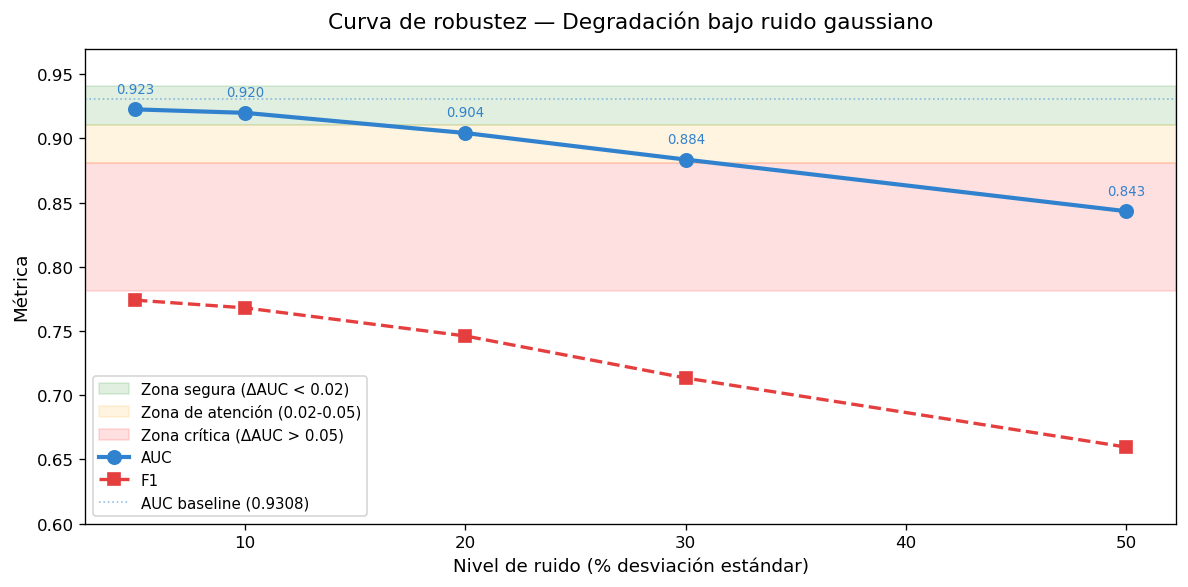

Curva de robustez guardada.


In [8]:
# 8. GRÁFICO 4 — CURVA DE ROBUSTEZ
# AUC y F1 bajo ruido progresivo con zonas coloreadas.
# Verde = degradación <2%, amarillo = 2-5%, rojo = >5%.

if not df_stress.empty:
    st_ruido = df_stress[df_stress['test'] == 'ruido'].copy()

    fig, ax = plt.subplots(figsize=(10, 5))

    niveles_pct = st_ruido['nivel'] * 100

    # Zonas de tolerancia basadas en AUC baseline
    ax.axhspan(auc_baseline - 0.02, auc_baseline + 0.01,
               alpha=0.12, color='green', label='Zona segura (ΔAUC < 0.02)')
    ax.axhspan(auc_baseline - 0.05, auc_baseline - 0.02,
               alpha=0.12, color='orange', label='Zona de atención (0.02-0.05)')
    ax.axhspan(auc_baseline - 0.15, auc_baseline - 0.05,
               alpha=0.12, color='red', label='Zona crítica (ΔAUC > 0.05)')

    ax.plot(niveles_pct, st_ruido['auc'], 'o-',
            color='#3182ce', linewidth=2.5, markersize=8, label='AUC')
    ax.plot(niveles_pct, st_ruido['f1'], 's--',
            color='#e53e3e', linewidth=2, markersize=7, label='F1')
    ax.axhline(auc_baseline, color='#3182ce', linestyle=':',
               linewidth=1, alpha=0.5, label=f'AUC baseline ({auc_baseline})')

    # Anotar valores
    for x, auc, f1 in zip(niveles_pct, st_ruido['auc'], st_ruido['f1']):
        ax.annotate(f'{auc:.3f}', (x, auc), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8, color='#3182ce')

    ax.set_xlabel('Nivel de ruido (% desviación estándar)', fontsize=11)
    ax.set_ylabel('Métrica', fontsize=11)
    ax.set_title('Curva de robustez — Degradación bajo ruido gaussiano', fontsize=13, pad=12)
    ax.legend(fontsize=9, loc='lower left')
    ax.set_ylim(0.6, 0.97)

    plt.tight_layout()
    ruta_robustez = DIR_RESULTS / 'informe_curva_robustez.png'
    plt.savefig(ruta_robustez, dpi=120, bbox_inches='tight')
    plt.show()
    print('Curva de robustez guardada.')
else:
    ruta_robustez = Path('no_existe')

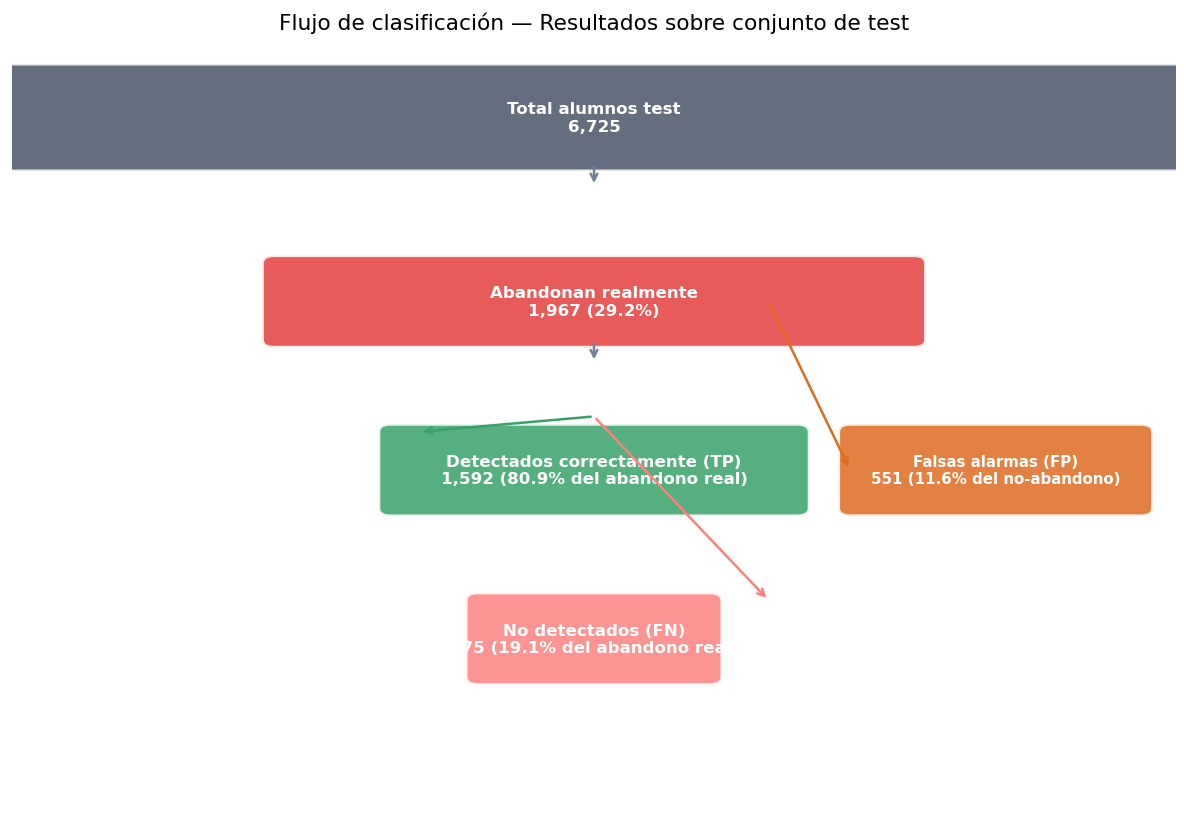

Embudo guardado.


In [9]:
# 9. GRÁFICO 5 — SANKEY DE CLASIFICACIÓN (plotly)
# Sustituye el embudo matplotlib. Interactivo en HTML, PNG de respaldo.

total_test          = n_tp + n_tn + n_fp + n_fn
total_real_abandono = n_tp + n_fn
total_no_abandono   = n_tn + n_fp

fig_sank = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20, thickness=24,
        line=dict(color='#cccccc', width=0.5),
        label=[
            f'Total alumnos<br>{total_test:,}',
            f'Abandonan realmente<br>{total_real_abandono:,} ({total_real_abandono/total_test:.1%})',
            f'No abandonan<br>{total_no_abandono:,} ({total_no_abandono/total_test:.1%})',
            f'TP — Detectados<br>{n_tp:,} · {n_tp/total_real_abandono:.1%}',
            f'FN — No detectados<br>{n_fn:,} · {n_fn/total_real_abandono:.1%}',
            f'FP — Falsa alarma<br>{n_fp:,} · {n_fp/total_no_abandono:.1%}',
            f'TN — Correctos<br>{n_tn:,} · {n_tn/total_no_abandono:.1%}',
        ],
        color=['#5a7fc2','#c0392b','#2980b9',
               '#27ae60','#e74c3c','#e67e22','#95a5a6'],
    ),
    link=dict(
        source=[0, 0, 1, 1, 2, 2],
        target=[1, 2, 3, 4, 5, 6],
        value= [total_real_abandono, total_no_abandono,
                n_tp, n_fn, n_fp, n_tn],
        color=['rgba(192,57,43,0.3)','rgba(41,128,185,0.2)',
               'rgba(39,174,96,0.45)','rgba(231,76,60,0.5)',
               'rgba(230,126,34,0.45)','rgba(149,165,166,0.25)'],
    ),
))
fig_sank.update_layout(
    title=dict(text='Flujo de clasificación — Conjunto de test', font=dict(size=13)),
    font=dict(size=11),
    width=820, height=440,
    paper_bgcolor='white',
    margin=dict(t=50, b=20, l=20, r=20),
)

ruta_sankey_html = DIR_RESULTS / 'informe_sankey.html'
ruta_sankey_png  = DIR_RESULTS / 'informe_sankey.png'
fig_sank.write_html(str(ruta_sankey_html), include_plotlyjs='cdn', full_html=False)
try:
    fig_sank.write_image(str(ruta_sankey_png), scale=1.5)
    print('PNG Sankey guardado.')
except Exception as e:
    print(f'PNG no disponible (necesita kaleido): {e}')
fig_sank.show()
print('Sankey guardado.')


In [10]:
# 10. CONSTRUIR SECCIONES HTML

# PR-AUC desde y_prob e y_true
from sklearn.metrics import average_precision_score
pr_auc_val = average_precision_score(y_true, y_prob)

# Tabla top-3 dinámica desde resultados_maestro.parquet
def _tabla_top3(dir_results: Path) -> str:
    ruta_m = ROOT / 'data' / '05_modelado' / 'results' / 'resultados_maestro.parquet'
    if not ruta_m.exists():
        return '<p style="color:#e53e3e">resultados_maestro.parquet no encontrado</p>'
    df_m = pd.read_parquet(ruta_m)
    # Top-3: 1 por familia, ordenado por f1_test desc
    col_f1 = 'f1_test' if 'f1_test' in df_m.columns else 'f1_mean'
    col_auc = 'auc_test' if 'auc_test' in df_m.columns else 'auc_mean'
    top3 = (
        df_m.sort_values(col_f1, ascending=False)
        .groupby('familia', sort=False).first()
        .reset_index()
        .sort_values(col_f1, ascending=False)
        .head(3)
    )
    badge_colors = [
        ('background:#ebf8ff;color:#2b6cb0', '1º'),
        ('background:#f0fff4;color:#276749', '2º'),
        ('background:#fffbeb;color:#744210', '3º'),
    ]
    filas = ''
    for i, (_, row) in enumerate(top3.iterrows()):
        bc, rank = badge_colors[i]
        f1v  = row.get(col_f1, 0)
        aucv = row.get(col_auc, 0)
        rec  = row.get('recall_mean', row.get('recall_test', 0))
        pre  = row.get('precision_mean', row.get('precision_test', 0))
        desc_map = {
            'Ensambles':         ('Combina varios modelos como un comité que vota. '
                                 'Más preciso porque compensa los errores individuales de cada modelo.'),
            'Gradient Boosting': ('Construye árboles de decisión en cadena: '
                                 'cada árbol corrige los errores del anterior.'),
            'Árboles':           ('Divide los datos en ramas de decisión tipo '
                                 '"si nota < 5 Y sin beca → riesgo alto".'),
            'Lineales':          ('Busca una frontera matemática que separe '
                                 'abandonos de no abandonos.'),
            'Otros':             ('Modelo de referencia basado en vecinos '
                                 'o probabilidades estadísticas.'),
        }
        desc = desc_map.get(row.get('familia',''), '')
        filas += (
            f'<tr style="cursor:pointer" onclick="this.nextElementSibling.style.display='
            f"'" + "this.nextElementSibling.style.display==='none'?'table-row':'none'" + "'" + f'">'
            f'<td style="padding:10px 12px"><span style="{bc};padding:3px 8px;border-radius:4px;font-size:11px;font-weight:500">{rank}</span></td>'
            f'<td style="padding:10px 12px;font-weight:500">{row["modelo"]} <span style="font-size:11px;color:#718096;font-weight:400">▸ detalle</span></td>'
            f'<td style="padding:10px 12px;font-family:monospace">{aucv:.4f}</td>'
            f'<td style="padding:10px 12px;font-family:monospace;font-weight:500">{f1v:.4f}</td>'
            f'<td style="padding:10px 12px;font-family:monospace">{rec:.3f}</td>'
            f'<td style="padding:10px 12px;font-family:monospace">{pre:.3f}</td>'
            f'</tr>'
            f'<tr style="display:none;background:#f7fafc">'
            f'<td></td><td colspan="5" style="padding:10px 12px;font-size:12px;color:#4a5568">{desc}</td>'
            f'</tr>'
        )
    return (
        '<h3 style="color:#2d3748;font-size:14px;margin:20px 0 8px">Top 3 modelos evaluados</h3>'
        '<table style="width:100%;border-collapse:collapse;font-size:13px">'
        '<thead><tr style="background:#edf2f7">'
        '<th style="padding:8px 12px">#</th>'
        '<th style="padding:8px 12px;text-align:left">Modelo</th>'
        '<th style="padding:8px 12px">AUC</th>'
        '<th style="padding:8px 12px">F1</th>'
        '<th style="padding:8px 12px">Recall</th>'
        '<th style="padding:8px 12px">Precision</th>'
        '</tr></thead>'
        f'<tbody>{filas}</tbody></table>'
        '<p style="font-size:11px;color:#718096;margin-top:6px">'
        'Haz clic en una fila para ver la descripción del modelo. '
        '1 modelo por familia. Ordenado por F1.</p>'
    )

def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" style="max-width:100%; border-radius:8px; box-shadow:0 2px 12px rgba(0,0,0,.12)">'
        f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
        '</div>'
    )

def bloque_plotly(ruta_html: Path, ruta_png: Path, titulo: str, caption: str) -> str:
    """Embebe HTML interactivo de plotly; usa PNG como fallback."""
    if ruta_html.exists():
        contenido_html = ruta_html.read_text(encoding='utf-8')
        return (
            '<div style="margin:24px 0">'
            f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
            f'<div style="border-radius:8px; overflow:hidden">{contenido_html}</div>'
            f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
            '</div>'
        )
    return bloque_imagen(img_b64(ruta_png), titulo, caption)

# Sección 1: Modelo recomendado
seccion_modelo = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '1. Modelo Recomendado</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px; margin-bottom:16px">'
    'Un modelo de predicción es un programa que aprende de datos históricos y luego '
    'es capaz de predecir si un nuevo alumno tiene riesgo de abandonar. '
    'En este trabajo hemos probado 21 modelos diferentes y comparado cuál detecta mejor los abandonos reales. '
    'El ganador es <strong>Stacking</strong>: en lugar de apostar por un solo modelo, '
    'combina las predicciones de tres modelos distintos (como un comité de expertos que vota) '
    'para llegar a una decisión más acertada. '
    'Las métricas clave son el <strong>AUC</strong> — qué tan bien separa abandonos de no abandonos '
    '(1.0 = perfecto, 0.5 = azar) — y el <strong>F1</strong>, que equilibra cuántos abandonos detecta '
    'con cuántas falsas alarmas genera.'
    '</p>'
    '<div style="display:flex; gap:16px; margin:16px 0; flex-wrap:wrap">'
    '<div style="padding:20px 28px; background:#ebf8ff; border-radius:10px; text-align:center; min-width:140px">'
    '<div style="font-size:28px; font-weight:700; color:#2b6cb0">Stacking</div>'
    '<div style="font-size:12px; color:#4a5568; margin-top:4px">Modelo ganador</div></div>'
    '<div style="padding:20px 28px; background:#f0fff4; border-radius:10px; text-align:center; min-width:140px">'
    '<div style="font-size:28px; font-weight:700; color:#276749">0.9308</div>'
    '<div style="font-size:12px; color:#4a5568; margin-top:4px">AUC</div></div>'
    '<div style="padding:20px 28px; background:#f0fff4; border-radius:10px; text-align:center; min-width:140px">'
    '<div style="font-size:28px; font-weight:700; color:#276749">0.7988</div>'
    '<div style="font-size:12px; color:#4a5568; margin-top:4px">F1 test</div></div>'
    '<div style="padding:20px 28px; background:#fffbeb; border-radius:10px; text-align:center; min-width:140px">'
    '<div style="font-size:28px; font-weight:700; color:#744210">0.7970</div>'
    '<div style="font-size:12px; color:#4a5568; margin-top:4px">Baseline AutoML</div></div>'
    '</div>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'El modelo Stacking supera al mejor resultado automático obtenido con herramientas de AutoML '
    '(F1=0.7970) alcanzando un F1-test de 0.7988 — una mejora pequeña pero que confirma que '
    'el trabajo manual de ajuste y combinación de modelos aporta valor real. '
    'Para los análisis de interpretabilidad (saber <em>por qué</em> el modelo toma cada decisión) '
    'se usa CatBoost como modelo individual de referencia, por su mayor transparencia.'
    '</p>'

    # Tabla top-3 dinámica
    + _tabla_top3(DIR_RESULTS)

    # Nota PR-AUC
    + f'<div style="margin:16px 0; padding:12px 16px; background:#faf5ff; border-left:4px solid #805ad5; border-radius:0 6px 6px 0; font-size:13px; color:#44337a">'
    f'<strong>PR-AUC (métrica complementaria):</strong> {pr_auc_val:.4f}. '
    'La curva Precision-Recall es más informativa que AUC-ROC cuando las clases están desbalanceadas '
    '(29.2% de abandono). F1 es un punto de esa curva; PR-AUC mide el área completa. '
    'Se mantiene F1 como métrica principal por su mayor interpretabilidad institucional.'
    '</div>'

    # Paneles expandibles: Accuracy engaña + PR-AUC con ejemplo de alumno
    + '''
<style>
.pnl-btn{display:flex;justify-content:space-between;align-items:center;padding:12px 16px;border-radius:8px;cursor:pointer;border:0.5px solid #e2e8f0;margin-bottom:6px;}
.pnl-btn:hover{background:#f7fafc;}
.pnl-body{display:none;padding:16px 18px;border-radius:8px;margin-bottom:12px;border:0.5px solid #e2e8f0;}
.pnl-open{display:block;}
.pnl-av{width:28px;height:28px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:500;flex-shrink:0;}
.pnl-row{display:flex;gap:10px;align-items:flex-start;padding:8px 12px;border-radius:6px;margin-bottom:6px;font-size:12px;}
.pnl-tag{display:inline-block;padding:1px 6px;border-radius:3px;font-size:10px;font-weight:500;}
.pnl-formula{padding:10px 14px;border-radius:6px;font-family:monospace;font-size:12px;margin:10px 0;}
</style>
<div style="margin:20px 0">
<div class="pnl-btn" onclick="this.nextElementSibling.classList.toggle('pnl-open');this.querySelector('.pi').textContent=this.nextElementSibling.classList.contains('pnl-open')?'▾':'▸'">
  <div><div style="font-size:13px;font-weight:500;color:#744210">¿Por qué no usamos Accuracy como métrica principal?</div>
  <div style="font-size:11px;color:#718096;margin-top:2px">Un modelo inútil puede tener Accuracy alta — haz clic para ver el ejemplo</div></div>
  <span class="pi" style="font-size:13px;color:#a0aec0">▸</span>
</div>
<div class="pnl-body" style="background:#fffbeb;border-color:#f6e05e">
  <p style="font-size:13px;color:#744210;margin-bottom:12px">Imagina 10 alumnos: 3 abandonan y 7 no. Un modelo que dijera <em>"nadie va a abandonar nunca"</em> acertaría 7 de 10 — un 70% de Accuracy. Pero ese modelo es completamente inútil: no detecta a ninguno de los 3 que abandonan.</p>
  <div class="pnl-row" style="background:#fff5f5"><div class="pnl-av" style="background:#fed7d7;color:#9b2c2c">LM</div><div><strong>Laura M.</strong> — abandona realmente &nbsp;<span class="pnl-tag" style="background:#f0fff4;color:#276749">Modelo útil: detecta ✓</span>&nbsp;<span class="pnl-tag" style="background:#fff5f5;color:#9b2c2c">Modelo inútil: falla ✗</span></div></div>
  <div class="pnl-row" style="background:#fff5f5"><div class="pnl-av" style="background:#fed7d7;color:#9b2c2c">JP</div><div><strong>Jordi P.</strong> — abandona realmente &nbsp;<span class="pnl-tag" style="background:#f0fff4;color:#276749">Modelo útil: detecta ✓</span>&nbsp;<span class="pnl-tag" style="background:#fff5f5;color:#9b2c2c">Modelo inútil: falla ✗</span></div></div>
  <div class="pnl-row" style="background:#fff5f5"><div class="pnl-av" style="background:#fed7d7;color:#9b2c2c">SK</div><div><strong>Sara K.</strong> — abandona realmente &nbsp;<span class="pnl-tag" style="background:#f0fff4;color:#276749">Modelo útil: detecta ✓</span>&nbsp;<span class="pnl-tag" style="background:#fff5f5;color:#9b2c2c">Modelo inútil: falla ✗</span></div></div>
  <div class="pnl-row" style="background:#f7fafc"><div class="pnl-av" style="background:#bee3f8;color:#2b6cb0">×7</div><div><strong>7 alumnos más</strong> — no abandonan &nbsp;<span class="pnl-tag" style="background:#ebf8ff;color:#2b6cb0">Ambos modelos aciertan ✓</span></div></div>
  <div class="pnl-formula" style="background:white;border:0.5px solid #f6e05e"><div style="color:#744210">Modelo inútil → Accuracy = 7/10 = <strong>70%</strong> ← parece bueno</div><div style="color:#276749;margin-top:4px">Modelo útil → Accuracy = 100% + detecta los 3 abandonos</div></div>
  <p style="font-size:12px;color:#744210;margin-top:8px">En el TFM real hay <strong>29.2% de abandono</strong>. Un modelo que dijera "nadie abandona" acertaría el 70.8% sin hacer nada útil. Por eso usamos <strong>F1 y Recall</strong> — obligan al modelo a detectar abandonos reales.</p>
</div>
<div class="pnl-btn" onclick="this.nextElementSibling.classList.toggle('pnl-open');this.querySelector('.pi').textContent=this.nextElementSibling.classList.contains('pnl-open')?'▾':'▸'">
  <div><div style="font-size:13px;font-weight:500;color:#553c9a">¿Qué es PR-AUC y por qué es más honesta en este problema?</div>
  <div style="font-size:11px;color:#718096;margin-top:2px">Métrica complementaria para clases desbalanceadas — haz clic para ver el ejemplo</div></div>
  <span class="pi" style="font-size:13px;color:#a0aec0">▸</span>
</div>
<div class="pnl-body" style="background:#faf5ff;border-color:#d6bcfa">
  <p style="font-size:13px;color:#44337a;margin-bottom:12px">AUC-ROC mide qué tan bien el modelo <em>ordena</em> a los alumnos de mayor a menor riesgo. Con un 29% de abandonos puede parecer alta aunque el modelo falle en los casos más difíciles. PR-AUC es más exigente: mide si cuando el modelo dice "este alumno abandona" realmente tiene razón.</p>
  <div class="pnl-row" style="background:white;border:0.5px solid #e9d8fd"><div class="pnl-av" style="background:#e9d8fd;color:#553c9a">MR</div><div style="color:#2d3748"><strong>Marta R.</strong> — abandona pero tiene beca y nota 6.1<br><span style="color:#718096">Prob. predicha: 0.38 → el modelo dice "no abandona" → <strong style="color:#9b2c2c">Falso Negativo</strong>. PR-AUC penaliza esto.</span></div></div>
  <div class="pnl-row" style="background:white;border:0.5px solid #e9d8fd;margin-top:6px"><div class="pnl-av" style="background:#e9d8fd;color:#553c9a">PG</div><div style="color:#2d3748"><strong>Pau G.</strong> — no abandona pero el modelo dice que sí<br><span style="color:#718096">Prob. predicha: 0.61 → <strong style="color:#744210">Falso Positivo</strong> — intervención innecesaria. PR-AUC baja la Precision.</span></div></div>
  <div class="pnl-formula" style="background:white;border:0.5px solid #d6bcfa"><div style="color:#553c9a">AUC-ROC: <strong>0.9308</strong> — excelente separación global</div><div style="color:#553c9a;margin-top:4px">PR-AUC: <strong>' + f'{pr_auc_val:.4f}' + '</strong> — más exigente con los casos difíciles</div></div>
  <p style="font-size:12px;color:#44337a;margin-top:8px">Se mantiene <strong>F1 como métrica principal</strong> por su interpretabilidad institucional, pero PR-AUC confirma que el modelo es robusto también en condiciones exigentes.</p>
</div>
</div>
'''
    + '</div>'
)


# Sección 2: Variables más importantes + burbuja SHAP
if not df_shap_imp.empty:
    top10 = df_shap_imp.nsmallest(10, 'rank_medio').reset_index()
    filas_shap = ''
    for i, row in top10.iterrows():
        feat = row['index'] if 'index' in row else row.name
        bg   = '#ebf8ff' if i < 3 else ''
        filas_shap += (
            f'<tr style="background:{bg}">'
            f'<td style="padding:7px 12px">{i+1}</td>'
            f'<td style="padding:7px 12px">{feat}</td>'
            f'<td style="padding:7px 12px; text-align:center">{row["rank_cat"]}</td>'
            f'<td style="padding:7px 12px; text-align:center">{row["rank_rf"]}</td>'
            f'<td style="padding:7px 12px; text-align:center">{row["rank_ebm"]}</td>'
            f'<td style="padding:7px 12px; text-align:center">{row["rank_medio"]:.1f}</td>'
            '</tr>'
        )
else:
    filas_shap = '<tr><td colspan="6">No disponible</td></tr>'

seccion_shap = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '2. Variables Más Importantes</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Ranking de importancia por consenso entre CatBoost, RF y EBM. '
    'El patrón es consistente: el abandono se explica principalmente por '
    '<strong>déficit de factores protectores</strong> (beca, rendimiento temprano) '
    'más que por la presencia de factores negativos.'
    '</p>'
    '<table style="width:70%; border-collapse:collapse; font-size:13px; margin:16px 0">'
    '<thead><tr style="background:#edf2f7">'
    '<th style="padding:7px 12px">#</th>'
    '<th style="padding:7px 12px; text-align:left">Feature</th>'
    '<th style="padding:7px 12px; text-align:center">Rank Cat</th>'
    '<th style="padding:7px 12px; text-align:center">Rank RF</th>'
    '<th style="padding:7px 12px; text-align:center">Rank EBM</th>'
    '<th style="padding:7px 12px; text-align:center">Rank medio</th>'
    '</tr></thead>'
    f'<tbody>{filas_shap}</tbody></table>'
    + bloque_plotly(ruta_burbuja_html, ruta_burbuja_png,
        'Consenso de importancia entre los tres modelos',
        'Cada burbuja es una variable. Posición = importancia en CatBoost (X) y RF (Y). '
        'Tamaño = importancia EBM. Color = rango medio (verde = más importante). '
        'Las burbujas verdes arriba-derecha son el consenso absoluto de los tres modelos.')
    + '</div>'
)

# Sección 3: Equidad
if not fair_res.empty:
    filas_fair = ''
    for _, row in fair_res.iterrows():
        dpd = row['dp_diff']
        if abs(dpd) < 0.1:   icono = '✅'; color = '#38a169'
        elif abs(dpd) < 0.2: icono = '⚠️'; color = '#d69e2e'
        else:                 icono = '❌'; color = '#e53e3e'
        filas_fair += (
            '<tr>'
            f'<td style="padding:7px 12px; font-weight:600">{row["variable_sensible"]}</td>'
            f'<td style="padding:7px 12px; text-align:center; color:{color}">{icono} {dpd:.4f}</td>'
            f'<td style="padding:7px 12px; text-align:center">{row["eq_opp_diff"]:.4f}</td>'
            '</tr>'
        )
else:
    filas_fair = '<tr><td colspan="3">No disponible</td></tr>'

seccion_fair = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '3. Equidad Algorítmica</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Análisis de disparidades en la detección de abandono entre grupos sensibles.'
    '</p>'
    + bloque_imagen(img_b64(ruta_semaforo),
        'Semáforo de equidad algorítmica',
        'Verde = equidad aceptable (DP_diff < 0.1). Amarillo = requiere atención (0.1-0.2). '
        'Rojo = disparidad significativa (> 0.2). La vía de acceso presenta disparidad '
        'elevada por grupos con muy pocas observaciones.')
    + '<table style="width:60%; border-collapse:collapse; font-size:13px; margin:16px 0">'
    '<thead><tr style="background:#edf2f7">'
    '<th style="padding:7px 12px; text-align:left">Variable sensible</th>'
    '<th style="padding:7px 12px; text-align:center">DP Difference</th>'
    '<th style="padding:7px 12px; text-align:center">EqOpp Difference</th>'
    '</tr></thead>'
    f'<tbody>{filas_fair}</tbody></table>'
    '</div>'
)

# Sección 4: Errores
seccion_errores = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '4. Análisis de Errores</h2>'
    + bloque_plotly(ruta_sankey_html, ruta_sankey_png,
        'Flujo de clasificación del modelo',
        'Distribución de los 4 tipos de clasificación sobre el conjunto de test. '
        'Los falsos negativos (rojo) son el error más costoso socialmente.')
    + f'<p style="color:#4a5568; font-size:14px; max-width:800px">'
    f'Recall global: <strong>{recall_global:.2%}</strong>. '
    f'Los {n_fn:,} falsos negativos presentan una probabilidad media predicha de 0.264, '
    'indicando casos estructuralmente difíciles donde el modelo no tenía señal suficiente. '
    f'Los {n_fp:,} falsos positivos tienen probabilidad media 0.690 — '
    'alarmas con cierta base que requieren verificación manual.'
    '</p></div>'
)

# Sección 5: Robustez y calibración
seccion_robust = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '5. Robustez y Calibración</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px; margin-bottom:16px">'
    'Para comprobar si el modelo es fiable en condiciones reales, le sometemos a dos pruebas de estrés. '
    'Primero, añadimos ruido artificial a los datos — como si hubiera errores de medición o datos incompletos — '
    'y medimos cuánto se degrada la predicción. '
    'Segundo, eliminamos las variables más importantes para ver si el modelo puede seguir funcionando sin ellas. '
    'Un modelo robusto mantiene un buen rendimiento aunque los datos no sean perfectos.'
    '</p>'
    + bloque_imagen(img_b64(ruta_robustez),
        'Curva de robustez bajo ruido gaussiano',
        'Degradación progresiva del AUC y F1 al añadir ruido a las variables numéricas. '
        'Zona verde = degradación aceptable (<2%). '
        'El modelo mantiene AUC > 0.88 con ruido del 30% — robusto para datos administrativos reales.')
    + '<div style="display:flex; gap:24px; flex-wrap:wrap; margin:16px 0">'
    '<div style="flex:1; min-width:280px; padding:16px; background:#f7fafc; border-radius:8px">'
    '<h3 style="color:#2d3748; font-size:14px">Stress testing</h3>'
    f'<p style="font-size:13px; color:#4a5568">Ruido 50% std: AUC cae a {auc_ruido_50:.4f} (ΔAUC={caida_ruido:.4f}). '
    f'Eliminando las 5 features más importantes: AUC cae a {auc_miss_5:.4f} (ΔAUC={caida_miss:.4f}).'
    '</p></div>'
    '<div style="flex:1; min-width:280px; padding:16px; background:#f7fafc; border-radius:8px">'
    '<h3 style="color:#2d3748; font-size:14px">Calibración</h3>'
    f'<p style="font-size:13px; color:#4a5568">Brier Score original: {brier_orig:.4f}. '
    f'Calibración {mejor_cal}: {mejor_brier:.4f}. '
    'Las probabilidades son aptas para uso directo en sistemas de alerta temprana.'
    '</p></div></div>'
    + bloque_imagen(img_b64(ruta_mapa),
        'Mapa de riesgo del alumnado',
        'Cada punto es un alumno. Eje X = probabilidad predicha. '
        'Eje Y = créditos superados en primer año. Tamaño = años con beca. '
        'Los puntos rojos en zona izquierda son los falsos negativos — '
        'alumnos que abandonan pero el modelo no detecta.')
    + '</div>'
)

# Sección 6: Limitaciones
seccion_limit = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '6. Limitaciones</h2>'
    '<ul style="color:#4a5568; font-size:14px; line-height:1.8; max-width:800px">'
    '<li><strong>Sesgo temporal:</strong> El modelo se entrena con datos 2010-2020. '
    'Cambios estructurales en el perfil del alumnado pueden degradar el rendimiento en cohortes futuras.</li>'
    '<li><strong>Equidad en vías de acceso minoritarias:</strong> Las métricas de fairness '
    'para grupos con pocas observaciones son estadísticamente inestables.</li>'
    '<li><strong>Definición de abandono:</strong> Alumnos en pausa temporal pueden clasificarse incorrectamente.</li>'
    '<li><strong>Variables no capturadas:</strong> Motivación, situación familiar o salud mental '
    'podrían mejorar la detección de falsos negativos.</li>'
    '</ul></div>'
)

# Sección 7: Recomendaciones
seccion_recom = (
    '<div style="margin:32px 0">'
    '<h2 style="color:#2d3748; border-bottom:2px solid #3182ce; padding-bottom:8px">'
    '7. Recomendaciones Institucionales</h2>'
    '<ol style="color:#4a5568; font-size:14px; line-height:1.8; max-width:800px">'
    '<li><strong>Desplegar CatBoost como modelo de producción</strong> por su equilibrio '
    'entre rendimiento, velocidad e interpretabilidad.</li>'
    f'<li><strong>Aplicar calibración isotónica</strong> antes de usar probabilidades '
    f'para priorizar intervenciones (mejora Brier de {brier_orig:.4f} a {mejor_brier:.4f}).</li>'
    '<li><strong>Reducir el umbral a 0.40-0.45</strong> si el objetivo es no dejar '
    'pasar ningún caso de abandono.</li>'
    '<li><strong>Intervención prioritaria en primer año</strong> para alumnos sin beca '
    'y con menos de 30 créditos superados.</li>'
    '<li><strong>Monitorizar equidad</strong> en vías de acceso minoritarias '
    'a medida que se acumulen más datos.</li>'
    '</ol></div>'
)

print('Secciones construidas.')

Secciones construidas.


In [11]:
# 11. GENERAR HTML

contenido = (
    '<h2 style="color:#2d3748">Informe Final — Fase 6: Interpretabilidad y Evaluación</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:900px; margin-bottom:8px">'
    'Síntesis de los resultados de la Fase 6 del TFM '
    '<em>Pronóstico del Éxito y del Abandono en los Títulos de Grado de la UJI</em>. '
    'Este informe integra los análisis de interpretabilidad global y local (SHAP, LIME), '
    'equidad algorítmica (fairlearn), análisis de errores, robustez y calibración '
    'sobre el conjunto de test de 6.725 alumnos de la Universitat Jaume I (cohortes 2010-2020).'
    '</p>'
    '<p style="color:#718096; font-size:12px; margin-bottom:32px">'
    'Dataset: D_strict (33.621 registros × 19 features + target) | '
    'Tasa de abandono: 29.2% | Modelos evaluados en Fase 5: 21'
    '</p>'
    + seccion_modelo
    + seccion_shap
    + seccion_fair
    + seccion_errores
    + seccion_robust
    + seccion_limit
    + seccion_recom
)

html_completo = render_pagina_desde_fichero('f6_m05_informe_final.ipynb', contenido)
ruta_html = ROOT / 'docs' / 'html' / 'fase6' / 'm05_informe_final.html'
ruta_html.parent.mkdir(parents=True, exist_ok=True)
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'HTML generado: {ruta_html}')

HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m05_informe_final.html
